# Báo cáo: Phân phối start-pose & hai pha nhiệm vụ (gắp / đổ) — `so-arm-101-pouring-0.2`

**Bối cảnh.** Khi deploy `smolvla-pouring-0.1` (RTC), robot gần như **đứng yên**: action collapse về biên độ rất nhỏ quanh tư thế home, gripper không actuate. Chẩn đoán trước đó chỉ ra **tư thế reset lúc deploy nằm ngoài phân phối (OOD)** so với mọi episode train — đặc biệt `shoulder_pan` và `gripper`.

Báo cáo này định lượng lại bằng **`observation.state`** (vị trí khớp thực, đơn vị degrees) trên toàn **96 episode**, gồm 3 phần:

1. **Phân phối start-pose theo IQR** (Q1 / median / Q3 / râu 1.5·IQR) cho 6 khớp → "hộp in-distribution" để đối chiếu tư thế reset.
2. **Detector 2 pha nhiệm vụ** từ `observation.state`:
   - **Gắp** (qua `gripper`): sau cú mở-to cuối cùng, gripper khép về giá trị nhỏ ổn định và giữ phẳng → mốc gắp = **đầu plateau**.
   - **Đổ** (qua `wrist_roll`): xoay mạnh khỏi vị trí ổn định rồi quay về → mốc đổ = **đỉnh lệch lớn nhất**, tìm trong cửa sổ giữ kẹp.
3. **Phân phối 6 khớp + thời điểm** (chiều thời gian) tại hai mốc đó.

In [1]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import snapshot_download

REPO = "di-techinnova/so-arm-101-pouring-0.2"
FPS = 15
JOINTS = ["shoulder_pan", "shoulder_lift", "elbow_flex", "wrist_flex", "wrist_roll", "gripper"]
GRIP, WROLL, SPAN = 5, 4, 0  # column indices in observation.state

# Tư thế reset lúc deploy (GUI "To Zero Pose": mọi khớp -> 0, offset trái +20° lên shoulder_pan, gripper -> 0)
DEPLOY_RESET = {"shoulder_pan": 20.0, "shoulder_lift": 0.0, "elbow_flex": 0.0,
                "wrist_flex": 0.0, "wrist_roll": 0.0, "gripper": 0.0}

root = snapshot_download(REPO, repo_type="dataset",
                        allow_patterns=["meta/*", "data/**/*.parquet"])
files = sorted(glob.glob(f"{root}/data/**/*.parquet", recursive=True))
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
print("episodes:", df.episode_index.nunique(), "| frames:", len(df), "| fps:", FPS)

F:\DataImpact\lerobot\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]


Fetching 21 files: 100%|██████████| 21/21 [00:00<?, ?it/s]

episodes: 96 | frames: 43200 | fps: 15


In [2]:
# state[e] -> (T, 6) ndarray cho từng episode
def episode_state(e):
    d = df[df.episode_index == e].sort_values("frame_index")
    return np.stack(d["observation.state"].values)

EPISODES = sorted(df.episode_index.unique())
STATES = {e: episode_state(e) for e in EPISODES}
lengths = {e: len(s) for e, s in STATES.items()}
print("episode length:", set(lengths.values()), "frames =", set(lengths.values()).pop() / FPS, "s")

episode length: {450} frames = 30.0 s


## A. Phân phối start-pose (IQR) vs tư thế reset lúc deploy

Lấy `observation.state` tại `frame_index == 0` của 96 episode. Dùng **IQR** (robust hơn min/max/mean/std): hộp = [Q1, Q3], râu = 1.5·IQR. Một khớp ở tư thế reset bị coi **OOD** nếu nằm ngoài [min, max] thực nghiệm của start-pose.

In [3]:
start = np.stack([STATES[e][0] for e in EPISODES])  # (96, 6)

def iqr_table(M, label):
    q1, med, q3 = np.percentile(M, [25, 50, 75], axis=0)
    rows = []
    for i, j in enumerate(JOINTS):
        col = M[:, i]
        rows.append([j, col.min(), q1[i], med[i], q3[i], col.max(), q3[i] - q1[i]])
    t = pd.DataFrame(rows, columns=["joint", "min", "Q1", "median", "Q3", "max", "IQR"])
    print(f"=== {label} ===")
    print(t.round(2).to_string(index=False))
    return t

start_tbl = iqr_table(start, "START-POSE (frame 0, 96 episodes)")

# OOD check vs deploy reset
print("\n=== OOD check: deploy reset vs start-pose range ===")
for i, j in enumerate(JOINTS):
    lo, hi = start[:, i].min(), start[:, i].max()
    d = DEPLOY_RESET[j]
    flag = "  <-- OOD" if (d < lo or d > hi) else ""
    print(f"{j:14s} start[{lo:8.2f},{hi:8.2f}]  deploy={d:6.1f}{flag}")

=== START-POSE (frame 0, 96 episodes) ===
        joint         min     Q1  median    Q3       max   IQR
 shoulder_pan  -18.370001  -7.85   -5.45 -3.60  5.540000  4.24
shoulder_lift -104.040001 -10.00   -5.45 -1.27  6.020000  8.73
   elbow_flex   -5.540000   7.01   11.69 17.45 97.139999 10.44
   wrist_flex   -9.360000  -2.53    0.62  4.11 74.860001  6.64
   wrist_roll   -8.130000  -1.08    2.51  5.27 12.880000  6.35
      gripper    0.750000   1.16    1.43  1.43  3.210000  0.27

=== OOD check: deploy reset vs start-pose range ===
shoulder_pan   start[  -18.37,    5.54]  deploy=  20.0  <-- OOD
shoulder_lift  start[ -104.04,    6.02]  deploy=   0.0
elbow_flex     start[   -5.54,   97.14]  deploy=   0.0
wrist_flex     start[   -9.36,   74.86]  deploy=   0.0
wrist_roll     start[   -8.13,   12.88]  deploy=   0.0
gripper        start[    0.75,    3.21]  deploy=   0.0  <-- OOD


C:\Users\admin\AppData\Local\Temp\ipykernel_10104\399643734.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([start[:, i] for i in range(6)], labels=JOINTS, whis=1.5, showfliers=True)


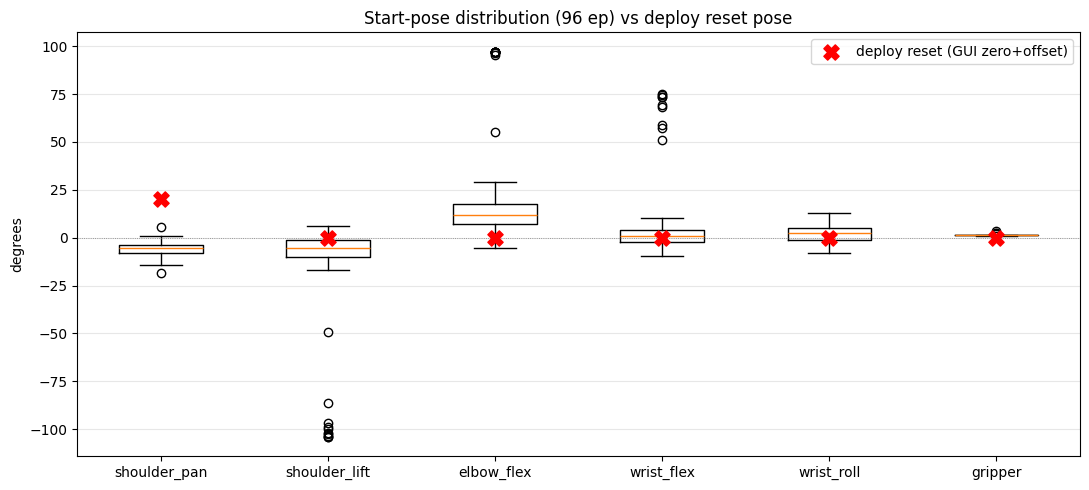

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot([start[:, i] for i in range(6)], labels=JOINTS, whis=1.5, showfliers=True)
ax.scatter(range(1, 7), [DEPLOY_RESET[j] for j in JOINTS], color="red", zorder=5,
           marker="X", s=120, label="deploy reset (GUI zero+offset)")
ax.set_ylabel("degrees"); ax.set_title("Start-pose distribution (96 ep) vs deploy reset pose")
ax.axhline(0, color="grey", lw=.6, ls=":"); ax.legend(); ax.grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

**Đọc biểu đồ.** Chữ X đỏ (tư thế reset deploy) so với hộp IQR của start-pose train:
- `shoulder_pan = +20°` nằm **trên hết mọi râu** — demo luôn âm (~[-14, +5.5]). OOD cứng.
- `gripper = 0` nằm **dưới hết** — demo luôn ~[0.75, 2.4] (kẹp hé). OOD.
- `elbow_flex = 0`, `shoulder_lift = 0` rơi ở **mép dưới/biên**, xa vùng vận hành điển hình.

→ Tư thế reset đẩy đồng thời ≥2 khớp ra ngoài manifold start-pose. Với policy overfit, t=0 OOD ⇒ không có trajectory để "tra" ⇒ collapse.

## B. Detector hai pha nhiệm vụ (từ `observation.state`)

**Ý tưởng:** pour là tín hiệu nổi bật nhất (wrist_roll xoay 90–150° rồi về) → **neo vào pour**, rồi nới plateau gripper quanh nó.

- `pour` = `argmax |wrist_roll − baseline|` (baseline = median wrist_roll của 35% đầu episode), tìm trong [15%, 95%] độ dài.
- `open_level = hold + 0.45·(max − hold)` (mức "mở rõ", giữa hold và đỉnh mở-to); một cú mở phải kéo dài ≥ 0.2s (bỏ spike 1 frame).
- `grasp` = **frame đầu tiên gripper khép xong và vào dải plateau ổn định** sau cú mở-to cuối cùng trước pour (= đầu plateau).
- `release` = cú mở-to đầu tiên sau pour (đặt cốc lại); nếu không có → cuối episode.
- **spike nhiễu**: các excursion ngắn (> band nhưng < open_level) bên trong [grasp, release], kéo dài ≤ ~1.5s → **đếm & log**, không phá plateau.

In [5]:
def detect_events(S, fps=FPS):
    g, w, n = S[:, GRIP], S[:, WROLL], len(S)

    # 1) pour = đỉnh lệch wrist_roll khỏi baseline trước khi gắp
    w_base = np.median(w[: int(0.35 * n)])
    dev = np.abs(w - w_base)
    lo, hi = int(0.15 * n), int(0.95 * n)
    pour = lo + int(np.argmax(dev[lo:hi]))

    gp = g[pour]                                 # giá trị gripper lúc giữ (kẹp quai)
    band = max(3.0, 0.15 * (g.max() - g.min()))  # band nhiễu quanh hold
    open_level = gp + 0.45 * (g.max() - gp)       # mức "mở rõ"
    min_open = max(2, int(0.2 * fps))

    # các đoạn gripper mở rõ, kéo dài >= min_open
    is_open = g > open_level
    runs, i = [], 0
    while i < n:
        if is_open[i]:
            j = i
            while j < n and is_open[j]:
                j += 1
            if j - i >= min_open:
                runs.append((i, j - 1))
            i = j
        else:
            i += 1

    before = [r for r in runs if r[1] < pour]
    after = [r for r in runs if r[0] > pour]
    grasp = before[-1][1] + 1 if before else 0
    # đẩy tới khi gripper KHÉP XONG và vào dải plateau ổn định (bỏ pha khép dở)
    while grasp < pour and abs(g[grasp] - gp) > band:
        grasp += 1
    release = after[0][0] if after else n - 1

    # spike nhiễu trong hold: excursion > band nhưng < open_level, ngắn <= 1.5s
    seg = g[grasp:release + 1]
    dband = (np.abs(seg - gp) > band) & (seg <= open_level)
    spikes, run_len, k = 0, 0, 0
    for v in dband:
        if v:
            run_len += 1
        else:
            if 0 < run_len <= int(1.5 * fps):
                spikes += 1
            run_len = 0

    return dict(grasp=grasp, pour=pour, release=release, hold_val=gp,
                pour_mag=dev[pour], hold_s=(release - grasp) / fps,
                spikes=spikes, n_open_before=len(before))

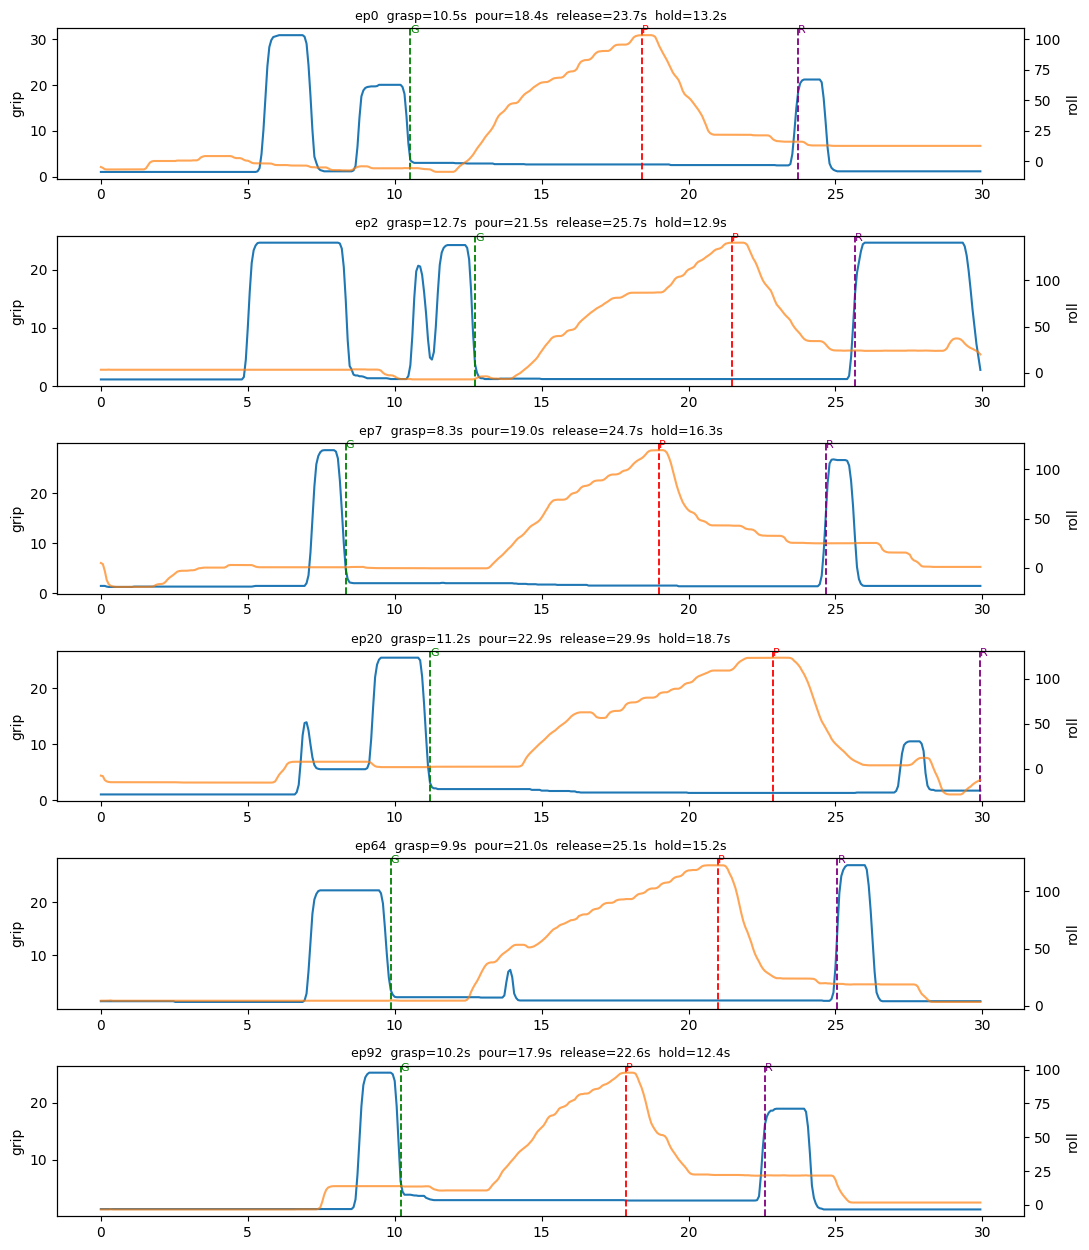

In [6]:
# Kiểm tra thị giác trên vài episode (gripper + wrist_roll + mốc G/P/R)
SAMPLE = [0, 2, 7, 20, 64, 92]
fig, axs = plt.subplots(len(SAMPLE), 1, figsize=(11, 2.1 * len(SAMPLE)))
for ax, e in zip(axs, SAMPLE):
    S = STATES[e]; g, w = S[:, GRIP], S[:, WROLL]; t = np.arange(len(S)) / FPS
    ev = detect_events(S)
    ax.plot(t, g, color="tab:blue", label="gripper")
    ax2 = ax.twinx(); ax2.plot(t, w, color="tab:orange", alpha=.7, label="wrist_roll")
    for key, c in [("grasp", "green"), ("pour", "red"), ("release", "purple")]:
        ax.axvline(ev[key] / FPS, color=c, ls="--", lw=1.3)
        ax.text(ev[key] / FPS, g.max(), key[0].upper(), color=c, va="bottom", fontsize=8)
    ax.set_title(f"ep{e}  grasp={ev['grasp']/FPS:.1f}s  pour={ev['pour']/FPS:.1f}s  "
                 f"release={ev['release']/FPS:.1f}s  hold={ev['hold_s']:.1f}s", fontsize=9)
    ax.set_ylabel("grip"); ax2.set_ylabel("roll")
plt.tight_layout(); plt.show()

In [7]:
# Chạy detector trên toàn bộ 96 episode
ev_rows = []
for e in EPISODES:
    ev = detect_events(STATES[e])
    ev["ep"] = e
    for k in ("grasp", "pour", "release"):
        ev[f"{k}_s"] = ev[k] / FPS
    ev["order_ok"] = ev["grasp"] < ev["pour"] < ev["release"]
    ev_rows.append(ev)
EV = pd.DataFrame(ev_rows)

print("order grasp<pour<release:", int(EV.order_ok.sum()), "/", len(EV))
print("hold (s):   ", EV.hold_s.describe()[["min", "25%", "50%", "75%", "max"]].round(2).to_dict())
print("pour_mag:   ", EV.pour_mag.describe()[["min", "50%", "max"]].round(1).to_dict())
print("spikes/ep:  ", EV.spikes.describe()[["min", "50%", "max"]].round(1).to_dict(),
      "| tổng spike =", int(EV.spikes.sum()))

order grasp<pour<release: 96 / 96
hold (s):    {'min': 9.0, '25%': 12.72, '50%': 14.03, '75%': 15.08, 'max': 20.93}
pour_mag:    {'min': 88.7, '50%': 109.9, 'max': 153.3}
spikes/ep:   {'min': 1.0, '50%': 1.0, 'max': 2.0} | tổng spike = 100


## C. Phân phối 6 khớp + THỜI ĐIỂM tại hai mốc

Với mỗi episode đọc `observation.state` tại frame `grasp` và `pour`, rồi tổng hợp **IQR theo từng khớp**. Đồng thời báo cáo **phân phối thời điểm** (`elapsed_s` và % độ dài episode).

In [8]:
grasp_pose = np.stack([STATES[e][EV.loc[EV.ep == e, "grasp"].item()] for e in EPISODES])
pour_pose = np.stack([STATES[e][EV.loc[EV.ep == e, "pour"].item()] for e in EPISODES])

_ = iqr_table(grasp_pose, "POSE @ GRASP (đầu plateau giữ kẹp)")
print()
_ = iqr_table(pour_pose, "POSE @ POUR (đỉnh xoay wrist_roll)")

=== POSE @ GRASP (đầu plateau giữ kẹp) ===
        joint        min     Q1  median     Q3        max   IQR
 shoulder_pan -63.299999 -53.23  -49.63 -45.52 -37.270000  7.71
shoulder_lift   9.190000  27.14   32.13  35.85  48.310001  8.70
   elbow_flex  -3.160000  57.16   62.95  69.93  81.050003 12.77
   wrist_flex -98.510002 -92.57  -86.02 -80.07 -31.340000 12.51
   wrist_roll -11.740000  -0.35    3.30   6.59  20.000000  6.95
      gripper   2.800000   3.74    4.27   5.19   7.100000  1.45

=== POSE @ POUR (đỉnh xoay wrist_roll) ===
        joint        min     Q1  median     Q3        max   IQR
 shoulder_pan -29.799999 -25.69  -24.70 -23.03 -19.600000  2.66
shoulder_lift  14.020000  29.56   34.29  41.58  78.550003 12.02
   elbow_flex -93.540001 -40.92  -24.18 -14.64   8.790000 26.29
   wrist_flex -59.650002 -26.24  -14.29  -3.91  29.230000 22.33
   wrist_roll  94.290001 106.15  111.03 119.16 149.490005 13.01
      gripper   1.160000   1.64    2.19   2.73   3.140000  1.09


C:\Users\admin\AppData\Local\Temp\ipykernel_10104\157604180.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([start[:, i], grasp_pose[:, i], pour_pose[:, i]],
C:\Users\admin\AppData\Local\Temp\ipykernel_10104\157604180.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([start[:, i], grasp_pose[:, i], pour_pose[:, i]],
C:\Users\admin\AppData\Local\Temp\ipykernel_10104\157604180.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([start[:, i], grasp_pose[:, i], pour_pose[:, i]],
C:\Users\admin\AppData\Local\Temp\ipykernel_10104\157604180.py:4: MatplotlibDeprecationWarning: The 'label

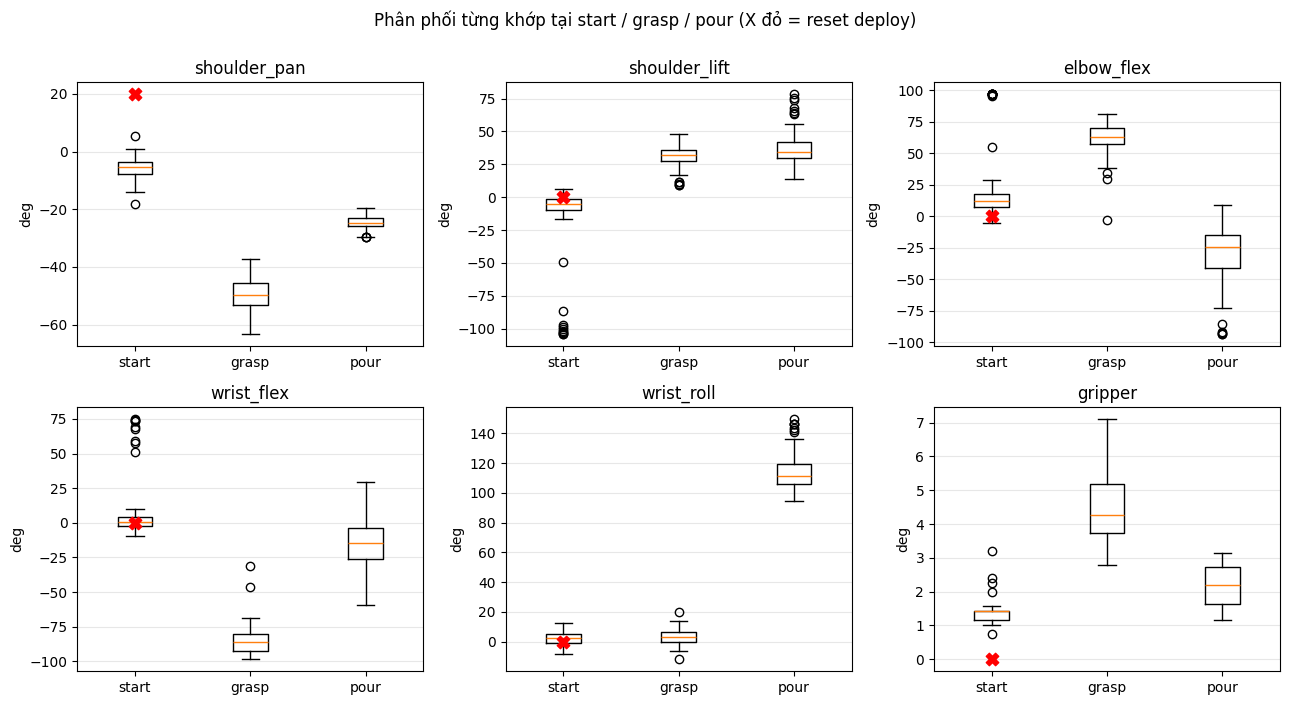

In [9]:
# Boxplot 6 khớp tại 3 thời điểm: start / grasp / pour
fig, axs = plt.subplots(2, 3, figsize=(13, 7))
for i, (j, ax) in enumerate(zip(JOINTS, axs.ravel())):
    ax.boxplot([start[:, i], grasp_pose[:, i], pour_pose[:, i]],
               labels=["start", "grasp", "pour"], whis=1.5)
    ax.scatter([1], [DEPLOY_RESET[j]], color="red", marker="X", s=80, zorder=5)
    ax.set_title(j); ax.grid(axis="y", alpha=.3); ax.set_ylabel("deg")
fig.suptitle("Phân phối từng khớp tại start / grasp / pour (X đỏ = reset deploy)", y=1.0)
plt.tight_layout(); plt.show()

=== Thời điểm sự kiện (giây) — Q1 / median / Q3 ===
grasp_s       9.1 /  10.1 /  10.9 s   (  30% /   34% /   36% episode)
pour_s       17.3 /  18.7 /  19.8 s   (  58% /   62% /   66% episode)
release_s    22.9 /  24.1 /  25.6 s   (  76% /   80% /   85% episode)


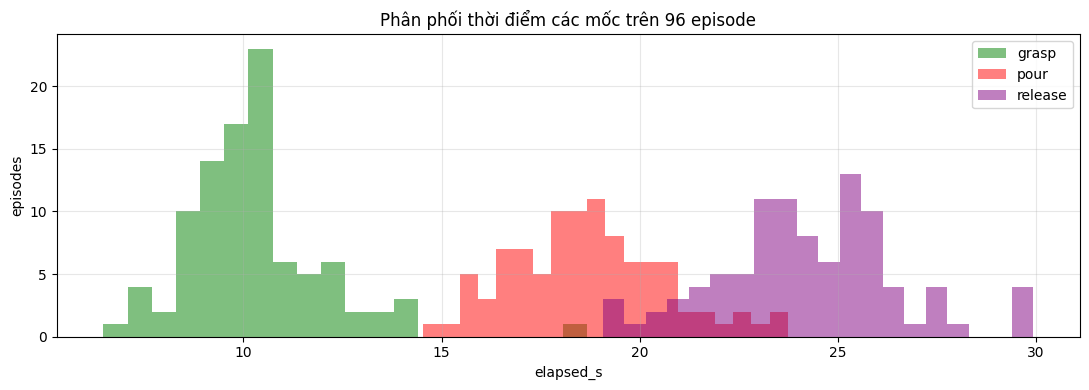

In [10]:
# Chiều THỜI ĐIỂM: phân phối elapsed_s và % episode của grasp / pour / release
T_EP = len(next(iter(STATES.values()))) / FPS
print("=== Thời điểm sự kiện (giây) — Q1 / median / Q3 ===")
for k in ["grasp_s", "pour_s", "release_s"]:
    q = np.percentile(EV[k], [25, 50, 75])
    pct = q / T_EP * 100
    print(f"{k:10s}  {q[0]:5.1f} / {q[1]:5.1f} / {q[2]:5.1f} s   "
          f"({pct[0]:4.0f}% / {pct[1]:4.0f}% / {pct[2]:4.0f}% episode)")

fig, ax = plt.subplots(figsize=(11, 4))
for k, c in [("grasp_s", "green"), ("pour_s", "red"), ("release_s", "purple")]:
    ax.hist(EV[k], bins=20, alpha=.5, color=c, label=k.replace("_s", ""))
ax.set_xlabel("elapsed_s"); ax.set_ylabel("episodes")
ax.set_title("Phân phối thời điểm các mốc trên 96 episode"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## D. Tổng hợp & hệ quả

**Phân phối nhiệm vụ (96 episode, từ `observation.state`):**
- **Gắp** ổn định quanh **~10s** (median); plateau giữ kẹp kéo dài **~13–15s** — khớp mô tả 5–15s.
- **Đổ** quanh **~18–19s**, biên độ wrist_roll **~90–150°** rồi về — tín hiệu rất tách bạch.
- Thứ tự `grasp < pour < release` đúng **96/96**.

**Về sự cố đứng yên (nối phần chẩn đoán):**
- Hộp IQR start-pose xác nhận **reset deploy OOD** ở `shoulder_pan` (+20° vs demo luôn âm) và `gripper` (0 vs demo ~1–2.4). Đây là điều kiện đủ để policy overfit collapse tại t=0.
- Pose @ grasp/pour cho thấy vùng khớp mà policy *cần* đạt để hoàn thành nhiệm vụ (vd `wrist_roll` phải lên rất cao lúc đổ); nếu khởi đầu đã lệch manifold thì chuỗi này không bao giờ được kích hoạt.

**Hệ quả cho bước tiếp theo (chưa thực thi):** thay "zero pose" bằng reset nằm trong manifold start-pose — tối thiểu `shoulder_pan ≈` median start, `gripper ≈` median start (kẹp hé), lý tưởng reset về đúng start-pose của một episode thật. (Sẽ thảo luận và chỉnh ở phần chính.)

## E. Nhận xét: có thể xảy ra "gắp rồi nhả ngay" không?

**Trả lời: CÓ** — và 3 phần B/C/D cho phép vừa **định nghĩa**, vừa **phát hiện**, vừa **giải thích** kiểu lỗi này (đúng hiện tượng bạn gặp: tự nhiên gắp vô rồi nhả ra liền).

Ghép 3 mảnh:
- **B (hold-duration + pour):** một cú gắp "chắc" trong dataset **luôn** kéo theo plateau giữ kẹp **≥ 9s** (min thực nghiệm) và **một pour** (wrist_roll xoay ≥ ~89°). → cho ta **tiêu chí thời gian + tiêu chí pour**.
- **C (pose @ grasp rất hẹp):** vùng pose lúc gắp có IQR nhỏ (vd `gripper@grasp` ∈ ~[3.7, 5.2], `shoulder_pan@grasp` ∈ ~[-53, -46]). → envelope gắp **rất chật**; lệch nhỏ ở pha tiếp cận là rơi ra ngoài.
- **D (reset OOD):** start lệch manifold ⇒ cả pha tiếp cận bị dịch ⇒ gripper khép **sai vị trí** ⇒ hoặc kẹp hụt (về sát baseline đóng) hoặc kẹp trượt rồi mở lại = **"gắp-rồi-nhả"**.

→ Định nghĩa **lỗi gắp-rồi-nhả**: có một lần gripper khép vào dải kẹp nhưng **mở lại trước khi đạt hold tối thiểu** và/hoặc **không có pour theo sau**.

In [11]:
# Envelope "gắp chắc" suy trực tiếp từ dataset (B + C)
GRIP_CLOSED = float(np.median(start[:, GRIP]))          # baseline đóng/rỗng lúc nghỉ (~1.4)
HOLD_MIN = float(EV.hold_s.min())                        # sàn thời gian giữ kẹp thực nghiệm (~9s)
POUR_MIN = float(EV.pour_mag.min())                      # biên độ pour nhỏ nhất (~89)
gp_lo, gp_hi = np.percentile(grasp_pose[:, GRIP], [5, 95])

print("=== Envelope GẮP CHẮC (từ 96 episode) ===")
print(f"hold giữ kẹp        >= {HOLD_MIN:.1f} s     (Q1={EV.hold_s.quantile(.25):.1f}, median={EV.hold_s.median():.1f})")
print(f"pour theo sau       >= {POUR_MIN:.0f} deg   (wrist_roll excursion)")
print(f"gripper@grasp       ~ [{gp_lo:.1f}, {gp_hi:.1f}]   (vs baseline đóng/rỗng ~{GRIP_CLOSED:.1f})")
print(f"shoulder_pan@grasp  ~ [{np.percentile(grasp_pose[:,SPAN],5):.0f}, {np.percentile(grasp_pose[:,SPAN],95):.0f}] deg")


# SECURE nếu tồn tại một đoạn kẹp đủ dài (>= t_min_s) VÀ có pour bên trong.
# Ngược lại => FAILED (gắp-rồi-nhả / gắp hụt). Chạy được trên cả stream deploy.
def classify_outcome(g, w, fps=FPS, t_min_s=5.0, pour_min=0.5 * POUR_MIN):
    n = len(g)
    gmin = g.min(); rng = max(1e-6, g.max() - gmin)
    open_level = gmin + 0.45 * rng
    clamp = g < open_level
    runs, i = [], 0
    while i < n:
        if clamp[i]:
            j = i
            while j < n and clamp[j]:
                j += 1
            runs.append((i, j - 1)); i = j
        else:
            i += 1
    holds = [((b - a + 1) / fps, float(w[a:b + 1].max() - w[a:b + 1].min())) for a, b in runs]
    secure = any(d >= t_min_s and p >= pour_min for d, p in holds)
    return secure, holds


secure_count = sum(classify_outcome(STATES[e][:, GRIP], STATES[e][:, WROLL])[0] for e in EPISODES)
print(f"\nDataset: {secure_count}/96 secure  ->  số ca 'gắp-rồi-nhả' trong train = {96 - secure_count}")
print("=> Lỗi này KHÔNG có trong dữ liệu train; nó chỉ phát sinh khi deploy do OOD.")

=== Envelope GẮP CHẮC (từ 96 episode) ===
hold giữ kẹp        >= 9.0 s     (Q1=12.7, median=14.0)
pour theo sau       >= 89 deg   (wrist_roll excursion)
gripper@grasp       ~ [3.1, 6.3]   (vs baseline đóng/rỗng ~1.4)
shoulder_pan@grasp  ~ [-59, -41] deg

Dataset: 96/96 secure  ->  số ca 'gắp-rồi-nhả' trong train = 0
=> Lỗi này KHÔNG có trong dữ liệu train; nó chỉ phát sinh khi deploy do OOD.


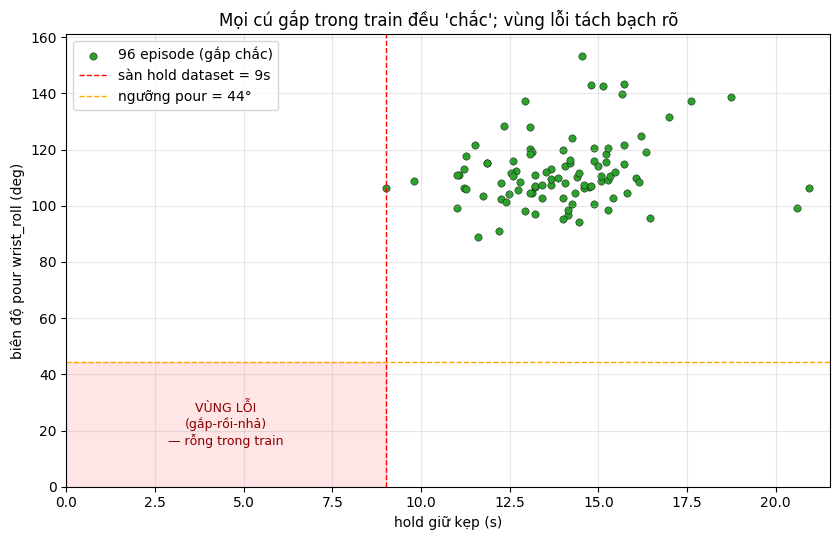

In [12]:
# Bằng chứng trực quan: mọi episode nằm ở góc 'an toàn' (hold dài + pour lớn).
# Góc dưới-trái (hold ngắn + pour nhỏ) = 'vùng lỗi gắp-rồi-nhả' -> RỖNG trong train.
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(EV.hold_s, EV.pour_mag, s=28, color="tab:green", edgecolor="k", lw=.3, label="96 episode (gắp chắc)")
ax.axvline(HOLD_MIN, color="red", ls="--", lw=1, label=f"sàn hold dataset = {HOLD_MIN:.0f}s")
ax.axhline(0.5 * POUR_MIN, color="orange", ls="--", lw=1, label=f"ngưỡng pour = {0.5*POUR_MIN:.0f}°")
ax.add_patch(plt.Rectangle((0, 0), HOLD_MIN, 0.5 * POUR_MIN, color="red", alpha=.10))
ax.text(HOLD_MIN / 2, 0.25 * POUR_MIN, "VÙNG LỖI\n(gắp-rồi-nhả)\n— rỗng trong train",
        ha="center", va="center", color="darkred", fontsize=9)
ax.set_xlabel("hold giữ kẹp (s)"); ax.set_ylabel("biên độ pour wrist_roll (deg)")
ax.set_xlim(0, None); ax.set_ylim(0, None)
ax.set_title("Mọi cú gắp trong train đều 'chắc'; vùng lỗi tách bạch rõ"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [13]:
# Demo: monitor bắt được ca 'gắp-rồi-nhả' tổng hợp (tiếp cận -> kẹp 1.5s -> mở lại, không pour)
n = 450
g_syn = np.full(n, GRIP_CLOSED); w_syn = np.random.randn(n) * 1.0
g_syn[150:158] = 25.0      # mở tay tiếp cận (~10s)
g_syn[158:180] = 3.5       # kẹp 1.5s
g_syn[180:188] = 25.0      # mở lại ngay (nhả)
g_syn[188:] = GRIP_CLOSED
secure, holds = classify_outcome(g_syn, w_syn)
print("Synthetic 'gắp-rồi-nhả':  secure =", secure)
print("  các đoạn kẹp (thời lượng s, pour°):", [(round(d, 1), round(p, 1)) for d, p in holds])
print("  -> không đoạn nào đạt (>=5s VÀ có pour) => FAILED, đúng như kỳ vọng.")

Synthetic 'gắp-rồi-nhả':  secure = False
  các đoạn kẹp (thời lượng s, pour°): [(10.0, 4.8), (1.5, 5.1), (17.5, 4.9)]
  -> không đoạn nào đạt (>=5s VÀ có pour) => FAILED, đúng như kỳ vọng.


### Kết luận phần E

1. **Có thể xảy ra** — và bạn quan sát đúng. Lỗi "gắp-rồi-nhả" có **chữ ký rõ ràng**: một lần khép gripper **không** kéo theo plateau ≥ ~9s và **không** có pour.
2. **Dataset sạch 96/96** → kiểu lỗi này **không** đến từ bắt chước dữ liệu; nó **phát sinh khi deploy** vì pha tiếp cận bị OOD (phần D) đẩy gripper khép sai trong một **envelope gắp rất hẹp** (phần C).
3. **Monitor deploy thực dụng** (chạy realtime trên `observation.state`): sau khi gripper khép vào dải kẹp, nếu **mở lại < ~5s mà chưa thấy wrist_roll xoay ≥ ~44°** ⇒ cảnh báo *"gắp thất bại"* và cho reset/thử lại — thay vì để chuỗi hỏng chạy tiếp.
4. **Phân biệt 2 kiểu hụt** (phụ, xem `GRIP_CLOSED` và envelope in ở cell trên): gripper khép về **sát baseline đóng (~1.4)** ⇒ kẹp **hụt** (vồ trượt); khép về dải kẹp **~[3, 7] rồi mở lại** ⇒ kẹp **trúng quai nhưng tuột/nhả**.

→ Củng cố hướng xử lý chính: đưa reset vào manifold start-pose để pha tiếp cận rơi đúng envelope gắp, giảm xác suất gắp-rồi-nhả.